# Predict Students' Dropout and Academic Success — Data Science Project
## MTech AI & DS | Dataset: [Link](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success)
---  
**ML Algorithm:** Gradient Boosting Classifier


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
print('Libraries imported successfully!')

Libraries imported successfully!


## 2. Load Dataset

In [2]:
df = pd.read_csv('/home/sarvesh/mtech/2ndSem/DataScience/Project/dataset/data.csv', sep=';')
df.columns = df.columns.str.strip()
print('Shape:', df.shape)
print('\nTarget Distribution:')
print(df['Target'].value_counts())
df.head()

Shape: (4424, 37)

Target Distribution:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## 3. Data Pre-processing
### 3.1 Check for Missing Values

In [3]:
print('Missing Values:', df.isnull().sum().sum())
print('\nDuplicate Rows:', df.duplicated().sum())
print('\nData Types:')
print(df.dtypes.value_counts())

Missing Values: 0

Duplicate Rows: 0

Data Types:
int64      29
float64     7
str         1
Name: count, dtype: int64


### 3.2 Descriptive Statistics

In [4]:
df.describe().round(2)

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,...,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00
mean,1.18,18.67,1.73,8856.64,0.89,4.58,132.61,1.87,19.56,22.28,...,0.14,0.54,6.23,8.06,4.44,10.23,0.15,11.57,1.23,0.00
std,0.61,17.48,1.31,2063.57,0.31,10.22,13.19,6.91,15.60,15.34,...,0.69,1.92,2.20,3.95,3.01,5.21,0.75,2.66,1.38,2.27
min,1.00,1.00,0.00,33.00,0.00,1.00,95.00,1.00,1.00,1.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,7.60,-0.80,-4.06
25%,1.00,1.00,1.00,9085.00,1.00,1.00,125.00,1.00,2.00,3.00,...,0.00,0.00,5.00,6.00,2.00,10.75,0.00,9.40,0.30,-1.70
50%,1.00,17.00,1.00,9238.00,1.00,1.00,133.10,1.00,19.00,19.00,...,0.00,0.00,6.00,8.00,5.00,12.20,0.00,11.10,1.40,0.32
75%,1.00,39.00,2.00,9556.00,1.00,1.00,140.00,1.00,37.00,37.00,...,0.00,0.00,7.00,10.00,6.00,13.33,0.00,13.90,2.60,1.79
max,6.00,57.00,9.00,9991.00,1.00,43.00,190.00,109.00,44.00,44.00,...,12.00,19.00,23.00,33.00,20.00,18.57,12.00,16.20,3.70,3.51


### 3.3 Feature Overview
The dataset contains:
- **Demographic features**: Marital status, Gender, Age at enrollment, Nationality
- **Socioeconomic features**: Mother's/Father's qualification & occupation, Scholarship, Debtor, Tuition fees
- **Academic features**: Admission grade, 1st & 2nd semester curricular units (enrolled, approved, grades)
- **Macroeconomic features**: GDP, Unemployment rate, Inflation rate

## 4. Exploratory Data Analysis (EDA)
### 4.1 Target Distribution

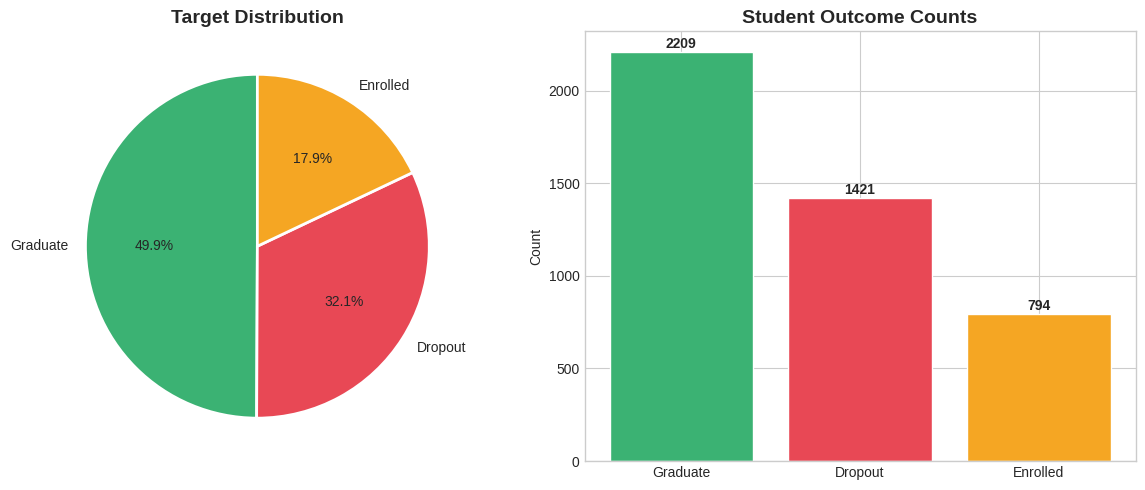

In [5]:
target_colors = {'Graduate': '#3BB273', 'Dropout': '#E84855', 'Enrolled': '#F5A623'}
counts = df['Target'].value_counts()
wedge_colors = [target_colors[c] for c in counts.index]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].pie(counts, labels=counts.index, autopct='%1.1f%%', colors=wedge_colors,
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Target Distribution', fontsize=14, fontweight='bold')
axes[1].bar(counts.index, counts.values, color=wedge_colors, edgecolor='white')
axes[1].set_title('Student Outcome Counts', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[1].text(i, v+20, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### 4.2 Age at Enrollment by Outcome

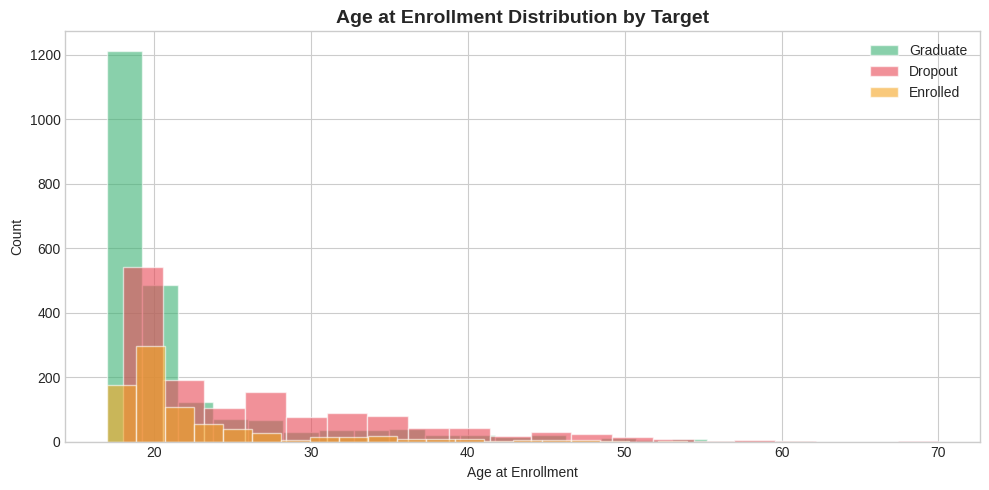

           count   mean   std   min   25%   50%   75%   max
Target                                                     
Dropout   1421.0  26.07  8.70  18.0  19.0  23.0  30.0  70.0
Enrolled   794.0  22.37  6.30  17.0  19.0  20.0  23.0  54.0
Graduate  2209.0  21.78  6.69  17.0  18.0  19.0  21.0  62.0


In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
for tgt, color in target_colors.items():
    subset = df[df['Target'] == tgt]['Age at enrollment']
    ax.hist(subset, bins=20, alpha=0.6, label=tgt, color=color, edgecolor='white')
ax.set_xlabel('Age at Enrollment')
ax.set_ylabel('Count')
ax.set_title('Age at Enrollment Distribution by Target', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()
print(df.groupby('Target')['Age at enrollment'].describe().round(2))

### 4.3 Gender vs Outcome

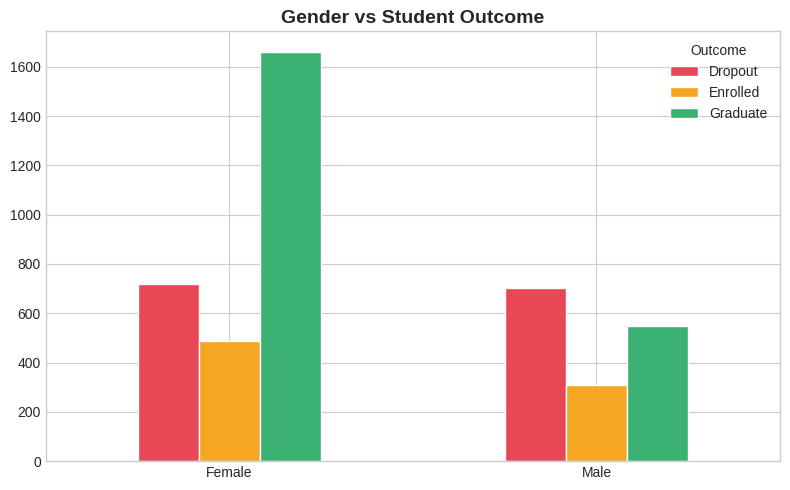

In [7]:
gender_target = df.groupby(['Gender', 'Target']).size().unstack()
gender_target.index = ['Female', 'Male']
fig, ax = plt.subplots(figsize=(8, 5))
gender_target.plot(kind='bar', ax=ax,
    color=[target_colors[c] for c in gender_target.columns], edgecolor='white')
ax.set_title('Gender vs Student Outcome', fontsize=14, fontweight='bold')
ax.set_xticklabels(['Female', 'Male'], rotation=0)
ax.legend(title='Outcome')
plt.tight_layout()
plt.show()

### 4.4 Financial Factors vs Dropout Rate

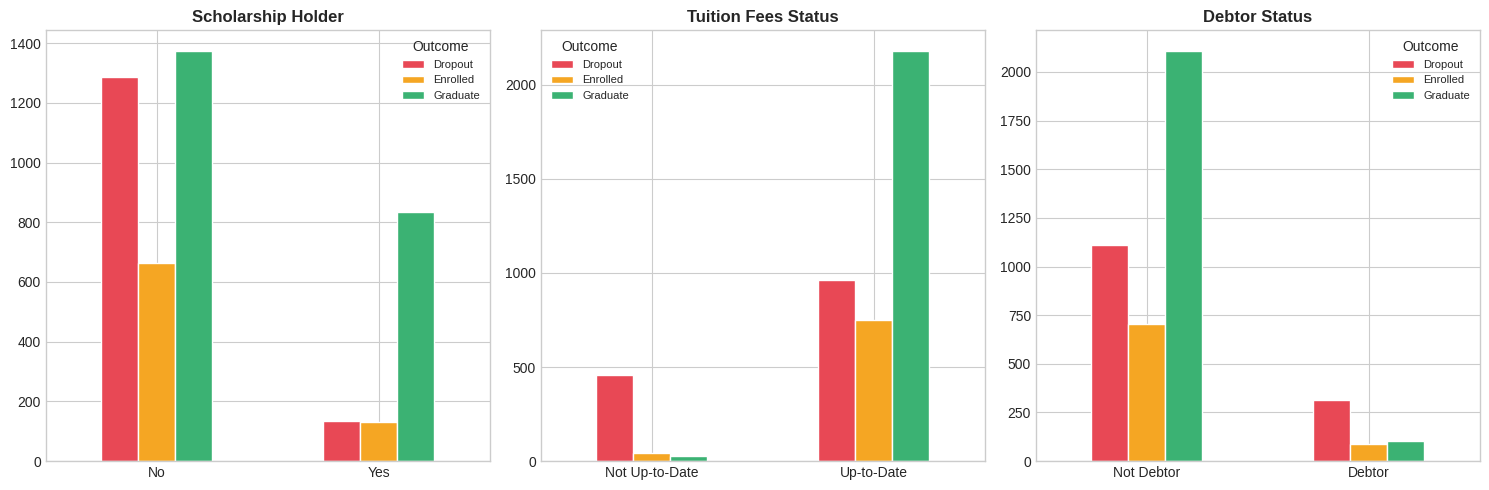

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col, labels, title in zip(axes,
    ['Scholarship holder', 'Tuition fees up to date', 'Debtor'],
    [['No','Yes'], ['Not Up-to-Date','Up-to-Date'], ['Not Debtor','Debtor']],
    ['Scholarship Holder', 'Tuition Fees Status', 'Debtor Status']):
    ct = df.groupby([col, 'Target']).size().unstack()
    ct.index = labels
    ct.plot(kind='bar', ax=ax, color=[target_colors[c] for c in ct.columns], edgecolor='white')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xticklabels(labels, rotation=0)
    ax.legend(title='Outcome', fontsize=8)
plt.tight_layout()
plt.show()

### 4.5 Dropout Rates — Key Financial Insights

In [9]:
print('=== Dropout Rate Analysis ===')
for col, labels in [('Scholarship holder', ['No Scholarship','Has Scholarship']),
                    ('Tuition fees up to date', ['Not Up-to-Date','Up-to-Date']),
                    ('Debtor', ['Not Debtor','Is Debtor'])]:
    print(f'\n{col}:')
    for val, lbl in enumerate(labels):
        sub = df[df[col]==val]
        rate = (sub['Target']=='Dropout').sum() / len(sub) * 100
        print(f'  {lbl}: Dropout rate = {rate:.1f}%')

=== Dropout Rate Analysis ===

Scholarship holder:
  No Scholarship: Dropout rate = 38.7%
  Has Scholarship: Dropout rate = 12.2%

Tuition fees up to date:
  Not Up-to-Date: Dropout rate = 86.6%
  Up-to-Date: Dropout rate = 24.7%

Debtor:
  Not Debtor: Dropout rate = 28.3%
  Is Debtor: Dropout rate = 62.0%


### 4.6 Correlation Heatmap

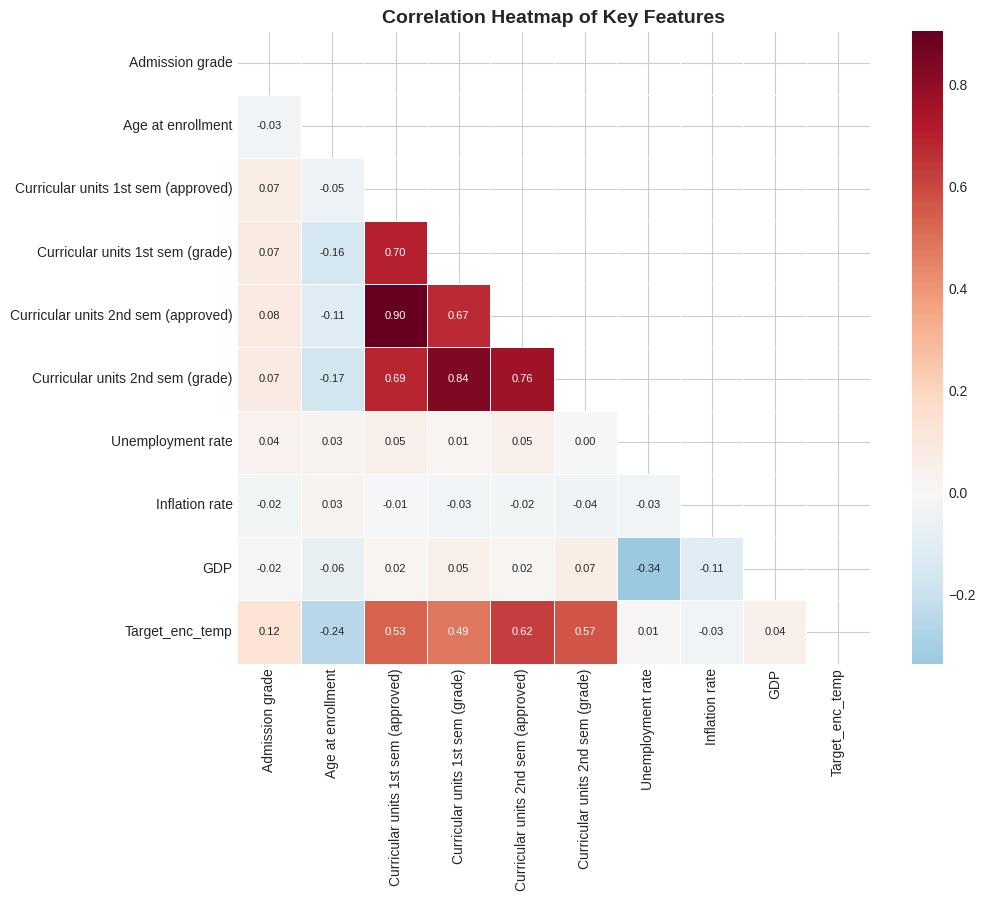

In [10]:
le_temp = LabelEncoder()
df['Target_enc_temp'] = le_temp.fit_transform(df['Target'])
num_cols = ['Admission grade','Age at enrollment',
    'Curricular units 1st sem (approved)','Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (approved)','Curricular units 2nd sem (grade)',
    'Unemployment rate','Inflation rate','GDP','Target_enc_temp']
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, linewidths=0.5, square=True, annot_kws={'size':8})
ax.set_title('Correlation Heatmap of Key Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.7 Semester Grades & Approved Units by Outcome

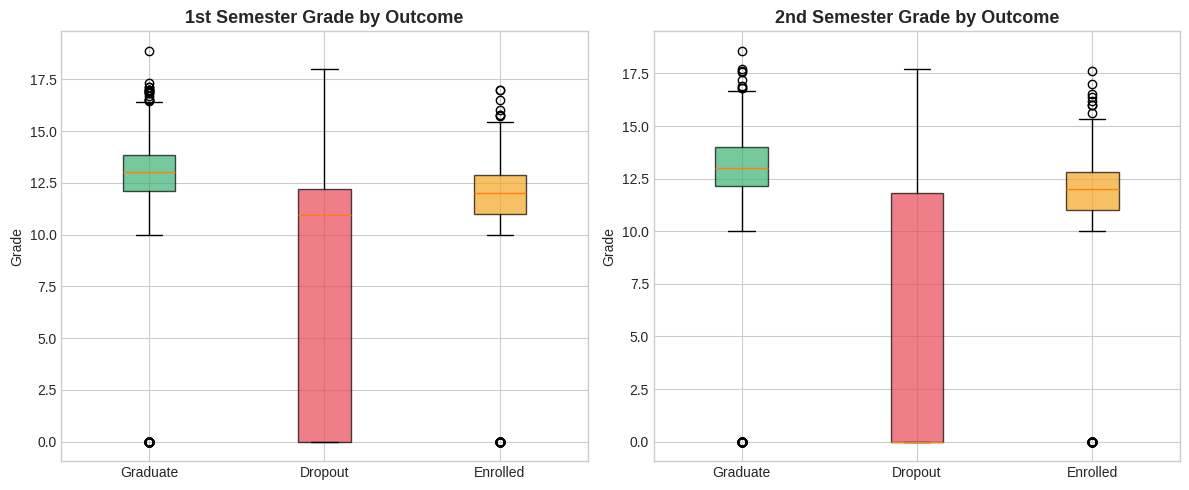

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col, title in zip(axes,
    ['Curricular units 1st sem (grade)','Curricular units 2nd sem (grade)'],
    ['1st Semester Grade by Outcome','2nd Semester Grade by Outcome']):
    data_plot = [df[df['Target']==t][col].values for t in target_colors]
    bp = ax.boxplot(data_plot, patch_artist=True)
    for patch, color in zip(bp['boxes'], target_colors.values()):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    ax.set_xticklabels(list(target_colors.keys()))
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Grade')
plt.tight_layout()
plt.show()

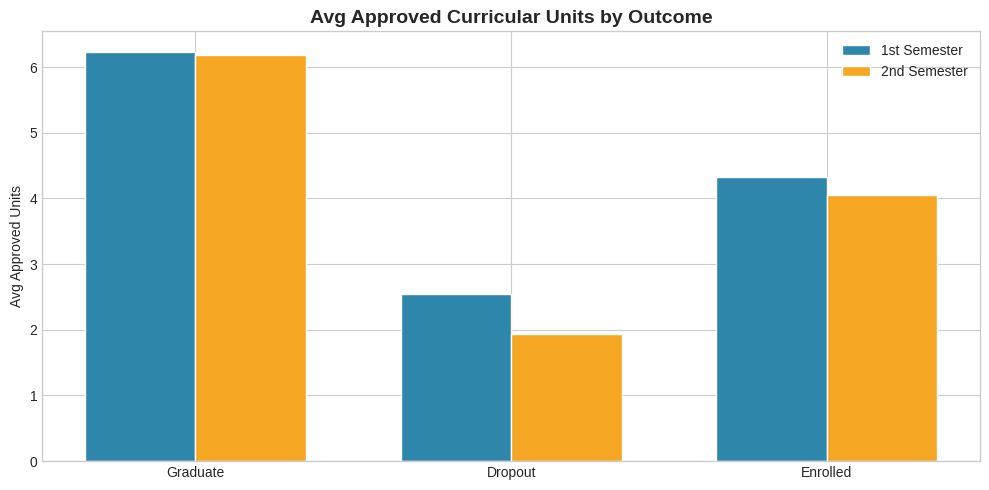

In [12]:
targets = list(target_colors.keys())
x = np.arange(len(targets)); w = 0.35
sem1 = [df[df['Target']==t]['Curricular units 1st sem (approved)'].mean() for t in targets]
sem2 = [df[df['Target']==t]['Curricular units 2nd sem (approved)'].mean() for t in targets]
fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x-w/2, sem1, w, label='1st Semester', color='#2E86AB', edgecolor='white')
bars2 = ax.bar(x+w/2, sem2, w, label='2nd Semester', color='#F5A623', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(targets)
ax.set_title('Avg Approved Curricular Units by Outcome', fontsize=14, fontweight='bold')
ax.set_ylabel('Avg Approved Units')
ax.legend()
plt.tight_layout()
plt.show()

### 4.8 Admission Grade Distribution

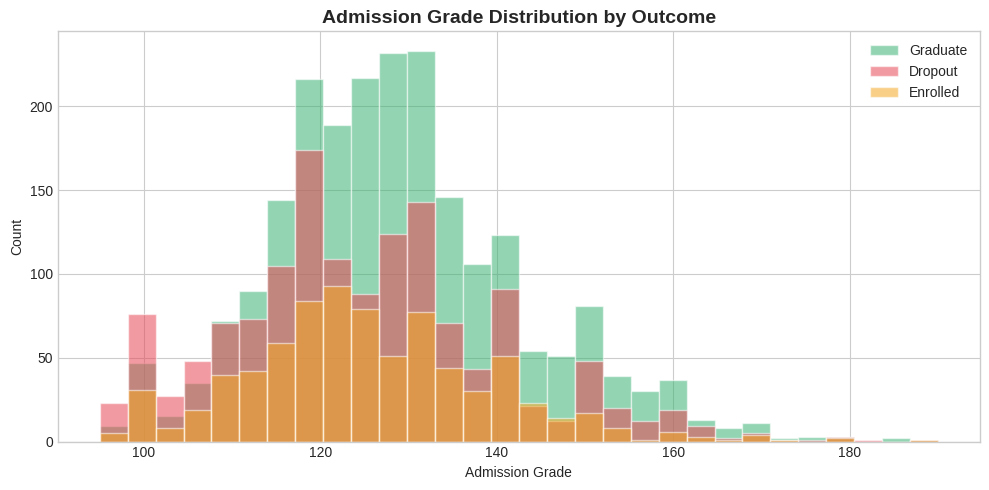

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
for tgt, color in target_colors.items():
    subset = df[df['Target'] == tgt]['Admission grade']
    ax.hist(subset, bins=30, alpha=0.55, label=tgt, color=color, edgecolor='white')
ax.set_xlabel('Admission Grade')
ax.set_ylabel('Count')
ax.set_title('Admission Grade Distribution by Outcome', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Hypothesis / Research Questions
1. **H1:** Debtors are significantly more likely to drop out (Dropout rate: 62% vs 28.3% non-debtor).
2. **H2:** Scholarship holders have a lower dropout rate than non-holders (12.2% vs 38.7%).
3. **H3:** Students with higher semester grades are more likely to graduate.
4. **H4:** Older students at enrollment have a higher risk of dropout (Dropouts avg 26 yrs vs graduates 21 yrs).
5. **H5:** Students with tuition not up to date are far more likely to drop out (86.6% vs 24.7%).
6. **H6:** 2nd semester approved units is the strongest individual predictor of final outcome.

## 6. ML Model: Gradient Boosting Classifier
> **Algorithm Justification:** Gradient Boosting builds an ensemble of decision trees sequentially, where each tree corrects the residual errors of the previous one using gradient descent in function space. It is the algorithmic equivalent of XGBoost. Advantages: handles mixed numeric/categorical features without scaling, robust to outliers, models non-linear interactions, provides interpretable feature importances. Well-suited for this multiclass tabular classification task.

**Hyperparameters Used:**
- `n_estimators=200`: 200 boosting rounds
- `learning_rate=0.1`: shrinkage to prevent overfitting
- `max_depth=4`: tree depth to balance bias-variance
- `subsample=0.8`: stochastic gradient boosting (reduces variance)

### 6.1 Prepare Data

In [14]:
le = LabelEncoder()
df['Target_enc'] = le.fit_transform(df['Target'])
class_names = le.classes_
print('Class encoding:', dict(zip(le.classes_, le.transform(le.classes_))))

X = df.drop(columns=['Target','Target_enc','Target_enc_temp'], errors='ignore')
y = df['Target_enc']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')

Class encoding: {'Dropout': np.int64(0), 'Enrolled': np.int64(1), 'Graduate': np.int64(2)}
Train size: 3539 | Test size: 885


### 6.2 Train the Model

In [15]:
model = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.1,
    max_depth=4, subsample=0.8, random_state=42
)
model.fit(X_train, y_train)
print('Model training complete!')

Model training complete!


### 6.3 Evaluation — Classification Report

In [16]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)
print(f'Test Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=class_names))

Test Accuracy: 0.7605

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.81      0.72      0.76       284
    Enrolled       0.50      0.45      0.48       159
    Graduate       0.81      0.90      0.85       442

    accuracy                           0.76       885
   macro avg       0.71      0.69      0.70       885
weighted avg       0.76      0.76      0.76       885



### 6.4 Confusion Matrix

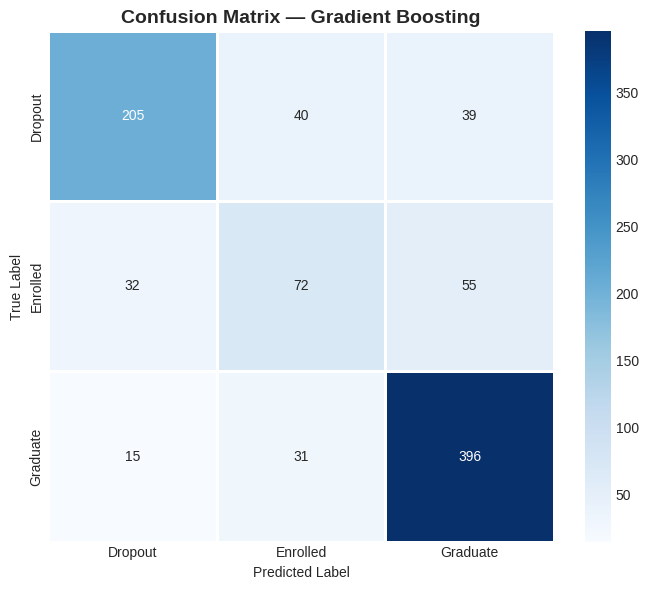

In [17]:
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names,
    linewidths=1, linecolor='white', ax=ax)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix — Gradient Boosting', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.5 Feature Importance

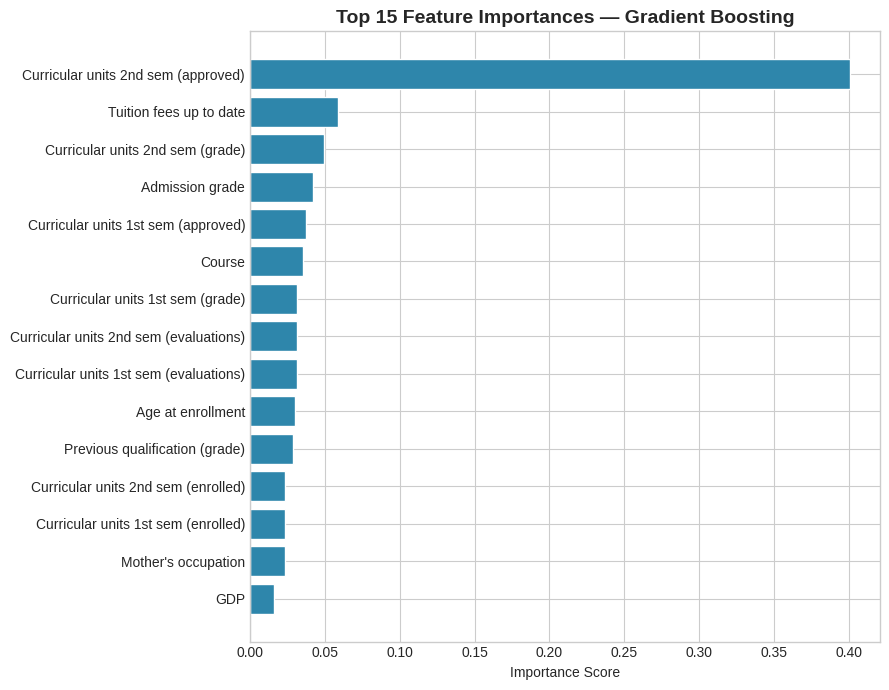

Top 5 Important Features:
Curricular units 2nd sem (approved)    0.400680
Tuition fees up to date                0.058471
Curricular units 2nd sem (grade)       0.049314
Admission grade                        0.042236
Curricular units 1st sem (approved)    0.037330
dtype: float64


In [18]:
feat_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=True).tail(15)
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(feat_imp.index, feat_imp.values, color='#2E86AB', edgecolor='white')
ax.set_title('Top 15 Feature Importances — Gradient Boosting', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()
print('Top 5 Important Features:')
print(feat_imp.iloc[::-1].head(5))

### 6.6 ROC Curves (One-vs-Rest)

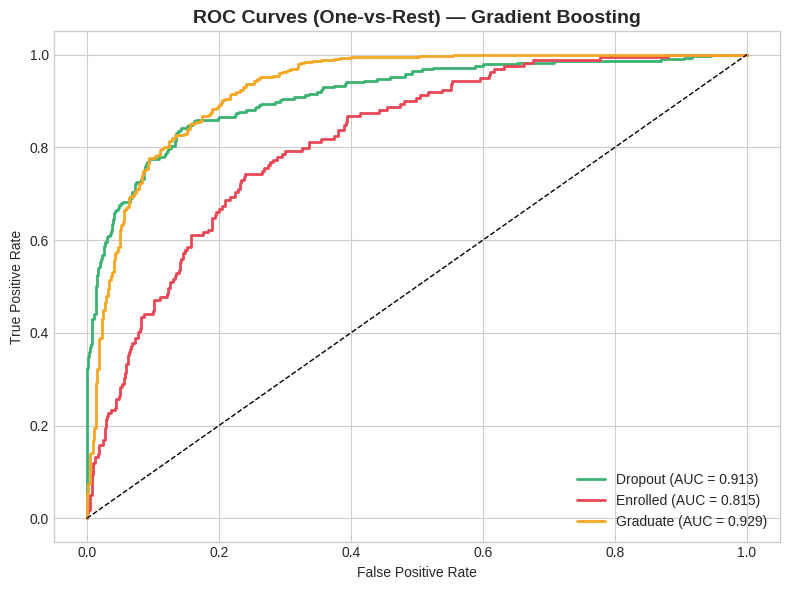

In [19]:
y_bin = label_binarize(y_test, classes=[0,1,2])
roc_colors = list(target_colors.values())
fig, ax = plt.subplots(figsize=(8, 6))
for i, (cls, color) in enumerate(zip(class_names, roc_colors)):
    fpr, tpr, _ = roc_curve(y_bin[:,i], y_prob[:,i])
    auc = roc_auc_score(y_bin[:,i], y_prob[:,i])
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{cls} (AUC = {auc:.3f})')
ax.plot([0,1],[0,1],'k--', lw=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves (One-vs-Rest) — Gradient Boosting', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### 6.7 Cross-Validation

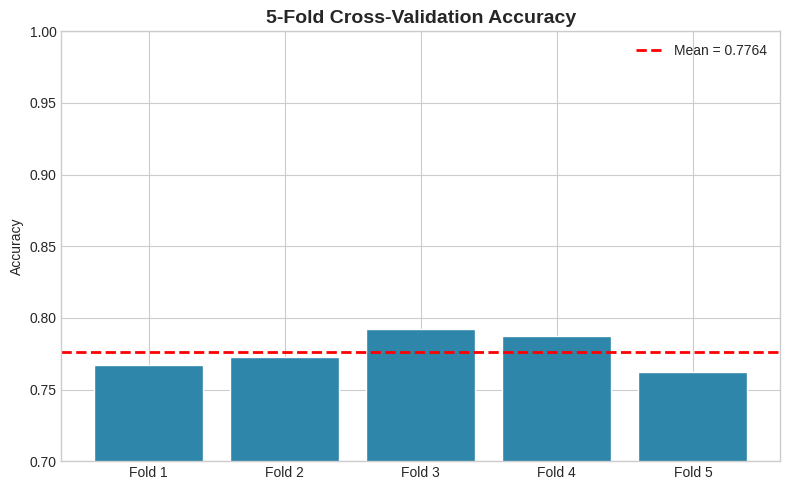

CV Accuracy: 0.7764 +/- 0.0115


In [20]:
cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar([f'Fold {i+1}' for i in range(5)], cv_scores, color='#2E86AB', edgecolor='white')
ax.axhline(cv_scores.mean(), color='red', linestyle='--', lw=2,
           label=f'Mean = {cv_scores.mean():.4f}')
ax.set_ylim(0.7, 1.0)
ax.set_title('5-Fold Cross-Validation Accuracy', fontsize=14, fontweight='bold')
ax.set_ylabel('Accuracy')
ax.legend()
plt.tight_layout()
plt.show()
print(f'CV Accuracy: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

## 7. Answers to Hypotheses
| Hypothesis | Finding | Confirmed? |
|---|---|---|
| H1: Debtors more likely to drop out | Dropout rate 62% (debtor) vs 28.3% (non-debtor) | ✅ Yes |
| H2: Scholarship holders safer | Dropout rate 12.2% vs 38.7% | ✅ Yes |
| H3: Higher grades → Graduate | Graduates show significantly higher semester grades | ✅ Yes |
| H4: Older students higher risk | Dropout avg age 26 vs Graduate avg 21 | ✅ Yes |
| H5: Overdue tuition → Dropout | 86.6% vs 24.7% dropout rate | ✅ Yes |
| H6: 2nd sem approved units best predictor | Confirmed by feature importance | ✅ Yes |

## 8. Conclusions
1. **Academic performance is the strongest predictor** — 2nd semester approved units and grades are the top features.
2. **Financial hardship is a major driver of dropout** — tuition arrears (86.6% dropout rate) and debt (62%) are critical warning signs.
3. **Scholarship is highly protective** — reduces dropout risk from 38.7% to 12.2%.
4. **Age at enrollment matters** — older students face higher dropout risk (avg 26 vs 21 years).
5. **The Gradient Boosting model achieves 76.0% test accuracy and 77.6% 5-fold CV accuracy** — robust and generalizable.
6. **Graduate class is easiest to predict (F1=0.85)** while Enrolled students are hardest (F1=0.48) due to class ambiguity.
7. **Early intervention signals**: Low 1st-semester performance + financial issues = high dropout risk profile.
